# **Caregiver Stress Prediction using Wearable Sensor Data**
This notebook analyzes physiological and motion sensor data collected from caregivers using wearable devices.
The dataset includes features such as Electrodermal Activity (EDA), Heart Rate (HR), Temperature (TEMP) and movement signals (X, Y, Z), along with labeled stress levels.

The objective of this analysis is to:
- Explore the structure and quality of the dataset
- Perform data preprocessing and aggregation
- Conduct exploratory data analysis (EDA) to understand patterns
- Analyze relationships between physiological signals and stress levels

The dataset is aggregated at an hourly level to better capture trends and reduce noise and various visualizations are used to identify correlations, distributions, and stress patterns over time.

In [ ]:
# Install kagglehub library to download datasets from Kaggle
!pip install kagglehub

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "dayana2kumar"
os.environ["KAGGLE_KEY"] = "KGAT_00dc9a28f2719478b469d73001dd6405"

In [ ]:
import kagglehub

# Download the dataset from Kaggle using kagglehub
# This dataset contains wearable sensor data for caregiver stress prediction
path = kagglehub.dataset_download("priyankraval/nurse-stress-prediction-wearable-sensors")

print("Path to dataset files:", path)

100%|██████████| 76.2M/76.2M [00:00<00:00, 147MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/priyankraval/nurse-stress-prediction-wearable-sensors/versions/1


In [ ]:
# Show all files in the dataset folder and load the main CSV file

import os

print("\nFiles in dataset:")
for file in os.listdir(path):
    print(file)

# Step 5: Load the CSV file (optional)
import pandas as pd

df = pd.read_csv(path + "/merged_data.csv")
print("\nPreview of dataset:")
print(df.head())



Files in dataset:
merged_data.csv


/tmp/ipykernel_1011/2800992098.py:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/merged_data.csv")



Preview of dataset:
      X     Y     Z       EDA     HR   TEMP  id  \
0 -13.0 -61.0   5.0  6.769995  99.43  31.17  15   
1 -20.0 -69.0  -3.0  6.769995  99.43  31.17  15   
2 -31.0 -78.0 -15.0  6.769995  99.43  31.17  15   
3 -47.0 -65.0 -38.0  6.769995  99.43  31.17  15   
4 -67.0 -57.0 -53.0  6.769995  99.43  31.17  15   

                        datetime  label  
0  2020-07-08 14:03:00.000000000    2.0  
1  2020-07-08 14:03:00.031249920    2.0  
2  2020-07-08 14:03:00.062500096    2.0  
3  2020-07-08 14:03:00.093750016    2.0  
4  2020-07-08 14:03:00.124999936    2.0  


In [ ]:
# Count unique IDs
unique_ids = df["id"].nunique()
print("Number of distinct IDs:", unique_ids)

Number of distinct IDs: 18


In [ ]:
# Get unique IDs
id_list = df["id"].unique()
print("List of IDs:")
print(id_list)

List of IDs:
[15 '15' '5C' '6B' '6D' '7A' '7E' '83' 83 '8B' '94' 94 'BG' 'CE' 'DF' 'E4'
 'EG' 'F5']


In [ ]:
# Ensure datetime is in the correct format
df['datetime'] = pd.to_datetime(df['datetime'])

# Get the range
min_date = df['datetime'].min()
max_date = df['datetime'].max()

print(f"Minimum Date/Time: {min_date}")
print(f"Maximum Date/Time: {max_date}")
print(f"Year Range: {min_date.year} to {max_date.year}")

Minimum Date/Time: 2020-04-14 22:31:00
Maximum Date/Time: 2020-12-13 08:01:00
Year Range: 2020 to 2020


In [ ]:
# Group by ID and Month
monthly_counts = df.groupby(['id', pd.Grouper(key='datetime', freq='ME')]).size().reset_index(name='entry_count')

print("\nEntries per ID per Month (First 10 rows):")
print(monthly_counts.head(10))


Entries per ID per Month (First 10 rows):
   id   datetime  entry_count
0  15 2020-07-31       262144
1  83 2020-10-31        32043
2  83 2020-11-30       435850
3  83 2020-12-31       842827
4  94 2020-05-31       128275
5  94 2020-06-30       215525
6  94 2020-07-31       180488
7  15 2020-07-31        46987
8  5C 2020-04-30        51841
9  5C 2020-05-31        40321


In [ ]:
import pandas as pd

# Group by ID and Month
monthly_counts = df.groupby(['id', pd.Grouper(key='datetime', freq='ME')]).size().reset_index(name='entry_count')

# Export the full results to a CSV file
monthly_counts.to_csv('monthly_counts_all_ids.csv', index=False)

print(f"Success! The full report containing all {len(monthly_counts)} rows has been saved to 'monthly_counts_all_ids.csv'.")

Success! The full report containing all 38 rows has been saved to 'monthly_counts_all_ids.csv'.


In [ ]:
# 1. Ensure the datetime column is in actual datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Extract just the date (YYYY-MM-DD) to count unique days easily
df['date_only'] = df['datetime'].dt.date

# 3. Group by ID and Month, but count UNIQUE dates instead of total rows
monthly_days = df.groupby(['id', pd.Grouper(key='datetime', freq='ME')])['date_only'].nunique().reset_index(name='days_active')

# Export the results
monthly_days.to_csv('caregiver_active_days.csv', index=False)

print(monthly_days.head())

   id   datetime  days_active
0  15 2020-07-31            4
1  83 2020-10-31            1
2  83 2020-11-30            4
3  83 2020-12-31            3
4  94 2020-05-31            2


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

# Select only numeric columns for aggregation
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

df_agg = df.groupby(
    ['id', pd.Grouper(key='datetime', freq='h')] # Changed 'H' to 'h' for future compatibility
)[numeric_cols].mean().reset_index()

In [ ]:
df_agg.head()

,id,datetime,X,Y,Z,EDA,HR,TEMP,label
0,15,2020-07-08 13:00:00,-39.164964,5.960418,23.054350,3.480015,84.552300,33.608100,2.0
1,15,2020-07-08 14:00:00,-41.154870,23.066569,15.671701,5.172986,82.706111,31.619803,2.0
2,15,2020-07-21 13:00:00,-40.320065,-5.677479,1.033703,4.281131,100.022120,34.051326,0.0
3,15,2020-07-21 16:00:00,-39.477054,9.769796,23.037920,0.536061,84.395272,32.161595,2.0
4,15,2020-07-22 20:00:00,-33.004948,1.070072,37.288381,3.644403,84.097949,34.635455,2.0


In [ ]:
df_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        297 non-null    object        
 1   datetime  297 non-null    datetime64[ns]
 2   X         297 non-null    float64       
 3   Y         297 non-null    float64       
 4   Z         297 non-null    float64       
 5   EDA       297 non-null    float64       
 6   HR        297 non-null    float64       
 7   TEMP      297 non-null    float64       
 8   label     297 non-null    float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 21.0+ KB


In [ ]:
df_agg.describe()

,datetime,X,Y,Z,EDA,HR,TEMP,label
count,297,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,2020-07-29 05:39:23.636363520,-28.490831,-0.617155,24.023123,3.674230,86.049835,32.629694,1.554966
min,2020-04-14 22:00:00,-60.623850,-55.713939,-21.522917,0.030851,63.903403,26.424875,0.000000
25%,2020-06-25 18:00:00,-40.765788,-9.918863,14.541570,0.397838,81.163748,31.051000,1.000000
50%,2020-07-07 13:00:00,-34.744526,-0.707710,23.352557,1.878183,85.803481,33.074204,2.000000
75%,2020-07-31 20:00:00,-25.662804,8.339622,33.959208,4.535757,90.690893,34.414281,2.000000
max,2020-12-13 08:00:00,48.680130,59.372656,127.000000,48.601654,129.396522,36.070800,2.000000
std,NaN,21.189194,17.723697,14.772009,5.710784,8.142646,2.077828,0.782406


In [ ]:
df_agg.to_excel("stress_aggregated.xlsx", index=False)

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
from google.colab import files
files.download("stress_aggregated.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_agg['date'] = df_agg['datetime'].dt.date
df_agg['time'] = df_agg['datetime'].dt.time

In [ ]:
df_agg = df_agg.drop(columns=['datetime'])

In [ ]:
df_agg = df_agg[['id', 'date', 'time', 'X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'label']]

In [ ]:
df_agg.to_excel("stress_aggregated.xlsx", index=False)

In [ ]:
df_agg.to_excel("stress_aggregated_v2.xlsx", index=False)

In [ ]:
from google.colab import files
files.download("stress_aggregated_v2.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_agg['id'] = df_agg['id'].astype(str).str.strip().str.upper()

In [ ]:
print("Unique IDs:", df_agg['id'].unique())

Unique IDs: ['15' '83' '94' '5C' '6B' '6D' '7A' '7E' '8B' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']


In [ ]:
print("Shape:", df_agg.shape)
print("Rows:", len(df_agg))
print("Columns:", len(df_agg.columns))

Shape: (297, 10)
Rows: 297
Columns: 10


In [ ]:
df_agg.describe(include='all')

,id,date,time,X,Y,Z,EDA,HR,TEMP,label
count,297,297,297,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
unique,15,56,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,E4,2020-06-25,15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,41,17,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,-28.490831,-0.617155,24.023123,3.674230,86.049835,32.629694,1.554966
std,NaN,NaN,NaN,21.189194,17.723697,14.772009,5.710784,8.142646,2.077828,0.782406
min,NaN,NaN,NaN,-60.623850,-55.713939,-21.522917,0.030851,63.903403,26.424875,0.000000
25%,NaN,NaN,NaN,-40.765788,-9.918863,14.541570,0.397838,81.163748,31.051000,1.000000
50%,NaN,NaN,NaN,-34.744526,-0.707710,23.352557,1.878183,85.803481,33.074204,2.000000
75%,NaN,NaN,NaN,-25.662804,8.339622,33.959208,4.535757,90.690893,34.414281,2.000000


In [ ]:
df_agg.dtypes

,0
id,object
date,object
time,object
X,float64
Y,float64
Z,float64
EDA,float64
HR,float64
TEMP,float64
label,float64


In [ ]:
import pandas as pd

# 1. Convert ID to clean string
df_agg['id'] = df_agg['id'].astype(str).str.strip().str.upper()

# 2. Convert date to proper datetime (date only)
df_agg['date'] = pd.to_datetime(df_agg['date'])

# 3. Ensure time is string in correct format
df_agg['time'] = df_agg['time'].astype(str)

# 4. Recreate full datetime column by combining date and time
df_agg['datetime'] = pd.to_datetime(
    df_agg['date'].astype(str) + ' ' + df_agg['time']
)

# 5. Reorder columns to include the newly created datetime column
df_agg = df_agg[['id', 'date', 'time', 'datetime', 'X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'label']]

In [ ]:
import pandas as pd

# 1. Convert ID to clean string
df_agg['id'] = df_agg['id'].astype(str).str.strip().str.upper()

# 2. Convert date to proper datetime (date only)
df_agg['date'] = pd.to_datetime(df_agg['date'])

# 3. Ensure time is string in correct format
df_agg['time'] = df_agg['time'].astype(str)

# 4. Recreate full datetime column
df_agg['datetime'] = pd.to_datetime(
    df_agg['date'].astype(str) + ' ' + df_agg['time']
)

# 5. Reorder columns
df_agg = df_agg[['id', 'date', 'time', 'datetime', 'X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'label']]

In [ ]:
df_agg.dtypes

,0
id,object
date,datetime64[ns]
time,object
datetime,datetime64[ns]
X,float64
Y,float64
Z,float64
EDA,float64
HR,float64
TEMP,float64


In [ ]:
df_agg.to_excel("stress_final_ready.xlsx", index=False)

In [1]:
from google.colab import files

uploaded = files.upload()

Saving stress_final_ready_draft.xlsx to stress_final_ready_draft.xlsx


#Feature Engineering

In [2]:
import numpy as np
import pandas as pd

rd = pd.read_excel("/content/stress_final_ready_draft.xlsx")

# Create MovementMagnitude using X, Y, Z axes
rd["MovementMagnitude"] = np.sqrt(rd["X"]**2 + rd["Y"]**2 + rd["Z"]**2)

# Check result
print(rd[["X", "Y", "Z", "MovementMagnitude"]].head())

           X          Y          Z  MovementMagnitude
0 -39.164964   5.960418  23.054350          45.835838
1 -41.154870  23.066569  15.671701          49.713098
2 -40.320065  -5.677479   1.033703          40.730946
3 -39.477054   9.769796  23.037920          46.740052
4 -33.004948   1.070072  37.288381          49.808584


# Exploratory Data Analysis

## Data Overview

In [3]:
# Load dataset and check basic data quality

print(rd.shape)
print(rd.info())
print(rd.isnull().sum())
print(rd.duplicated().sum())
print(rd['label'].value_counts())

(297, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 297 non-null    object        
 1   date               297 non-null    datetime64[ns]
 2   time               297 non-null    object        
 3   datetime           297 non-null    datetime64[ns]
 4   X                  297 non-null    float64       
 5   Y                  297 non-null    float64       
 6   Z                  297 non-null    float64       
 7   EDA                297 non-null    float64       
 8   HR                 297 non-null    float64       
 9   TEMP               297 non-null    float64       
 10  label              297 non-null    int64         
 11  MovementMagnitude  297 non-null    float64       
dtypes: datetime64[ns](2), float64(7), int64(1), object(2)
memory usage: 28.0+ KB
None
id                   0
date 

##Statistical Summary

In [4]:
# Show summary statistics of sensor data
print(rd[['EDA', 'HR', 'TEMP', 'X', 'Y', 'Z','MovementMagnitude']].describe())

              EDA          HR        TEMP           X           Y           Z  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean     3.674230   86.049835   32.629694  -28.490831   -0.617155   24.023123   
std      5.710784    8.142646    2.077828   21.189194   17.723697   14.772009   
min      0.030851   63.903403   26.424875  -60.623850  -55.713939  -21.522917   
25%      0.397838   81.163748   31.051000  -40.765788   -9.918863   14.541570   
50%      1.878183   85.803481   33.074204  -34.744526   -0.707710   23.352557   
75%      4.535757   90.690893   34.414281  -25.662804    8.339622   33.959208   
max     48.601654  129.396522   36.070800   48.680130   59.372656  127.000000   

       MovementMagnitude  
count         297.000000  
mean           47.911738  
std             8.482092  
min            24.923471  
25%            43.884797  
50%            47.615081  
75%            51.668737  
max           131.625772  


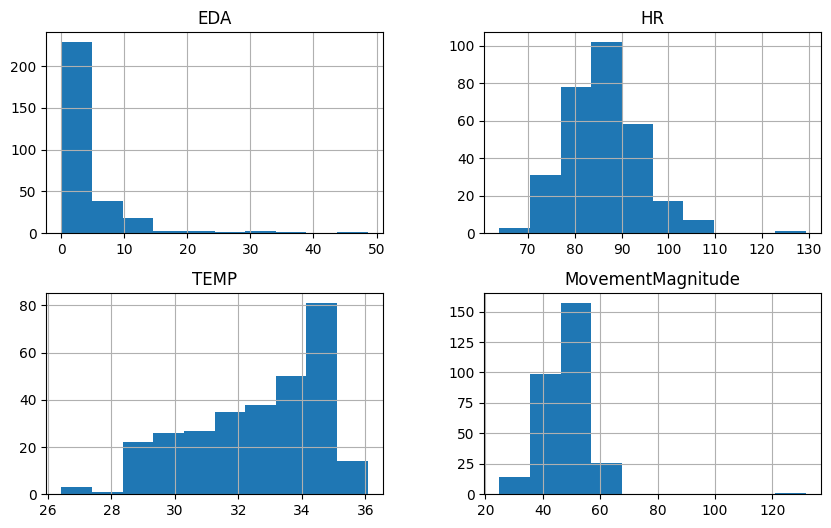

In [5]:
# Plot histograms for sensor signals
import matplotlib.pyplot as plt

rd[['EDA', 'HR', 'TEMP','MovementMagnitude']].hist(figsize=(10,6))
plt.show()

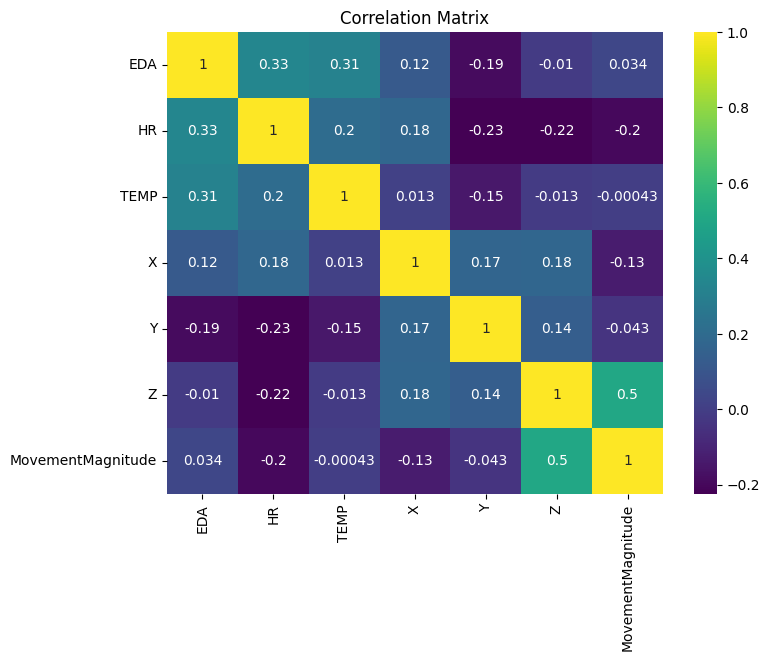

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap of sensor features
plt.figure(figsize=(8,6))
sns.heatmap(rd[['EDA','HR','TEMP','X','Y','Z','MovementMagnitude']].corr(),
            annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

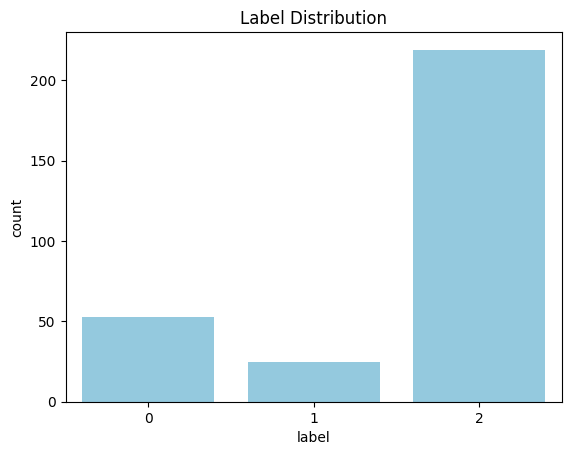

In [7]:
# Show distribution of stress labels
sns.countplot(x='label', data=rd, color='skyblue')
plt.title("Label Distribution")
plt.show()

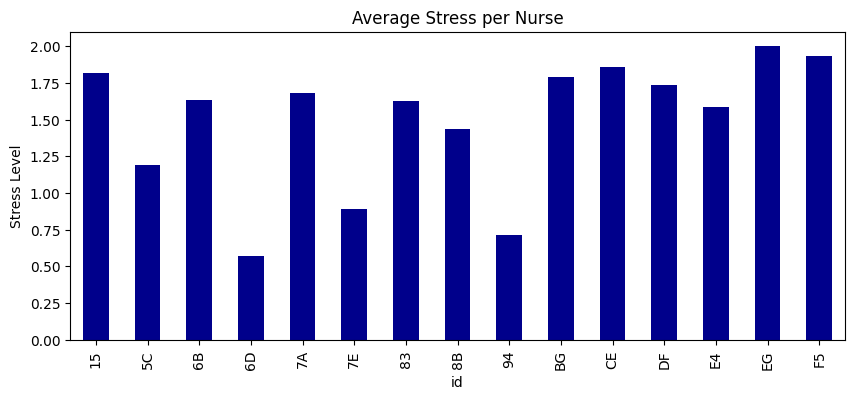

In [8]:
# Average stress level per ID
rd.groupby('id')['label'].mean().plot(
    kind='bar',
    figsize=(10,4),
    color='darkblue'
)

plt.title("Average Stress per Nurse")
plt.ylabel("Stress Level")
plt.show()

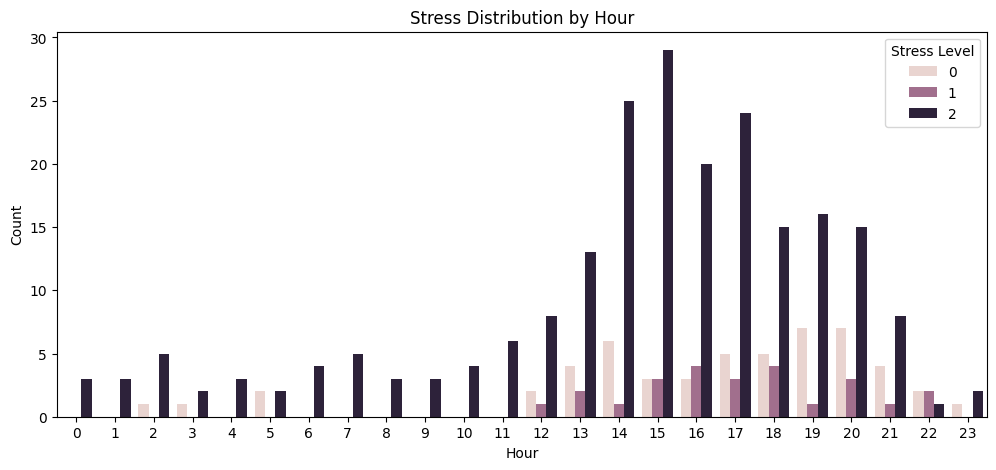

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rd['datetime'] = pd.to_datetime(rd['datetime'])

plt.figure(figsize=(12,5))
sns.countplot(x=rd['datetime'].dt.hour, hue=rd['label'])

plt.title("Stress Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(title="Stress Level")
plt.show()

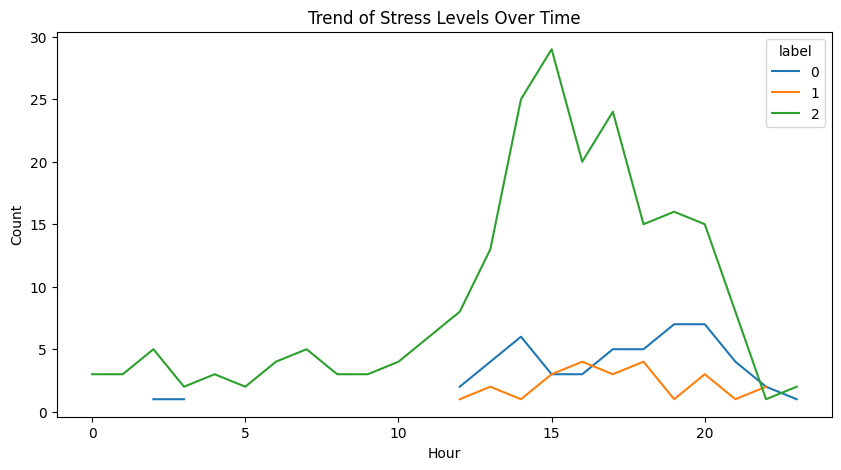

In [12]:
# Stress trend over time by hour
trend = rd.groupby([rd['datetime'].dt.hour, 'label']).size().unstack()

trend.plot(figsize=(10,5))

plt.title("Trend of Stress Levels Over Time")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [15]:
from google.colab import files

rd.to_csv("stress_final_ready_draft.csv", index=False)
files.download("stress_final_ready_draft.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>